In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *
from scipy.optimize import root
from matplotlib.colors import LogNorm
from scipy.optimize import least_squares
import pickle
from pathlib import Path

s = Simulation()
tg = 1000
sigma = 0.3
N_t = 500
tlist = np.linspace(0, tg, N_t)
rW = 2

In [ ]:
'''
    W_elemt : dict
        such that W_elemt[r,l,a] is the dictionnary of all {p: <<l, p|W_r|a, n_a>>} for r <= rW, (a, n_a) any resonant state, l any state of the system, and p any harmonics.
        Must be used as an argument of the function `dynamics_eff()`
'''
def h_sambe(t, wd, amp):
    ht_array, ht_args = h_target(Delta, rrr, tg, use_drag=True, sigma_r = sigma)
    ht = sum_list(ht_array)(t)
    # transformation into sambe space
    W_elemt = W_Floquet_elements(rW, wd, s.resonances, s.E_array, amp/2 * s.V1_dressed_array,
                        None, ref_state = None, analytics = False)
    W = np.zeros((3,3), dtype = complex)
    for il, l in enumerate(s.resonances):
        for ia, a in enumerate(s.resonances):
            la_dic = W_elemt[rW, l, a]
            # W[il,ia] = sum(la_dic[p] for p in la_dic.keys())
            p_l = s.resonances[l]
            W[il, ia] = 0 if not p_l in la_dic else la_dic[p_l]
    Wdag = Qobj(W.conj().T)
    return Wdag * ht * Qobj(W)

def Wmat(wd, amp):
    W_elemt = W_Floquet_elements(rW, wd, s.resonances, s.E_array, amp/2 * s.V1_dressed_array,
                        None, ref_state = None, analytics = False)
    W = np.zeros((3,3), dtype = complex)
    for il, l in enumerate(s.resonances):
        for ia, a in enumerate(s.resonances):
            la_dic = W_elemt[rW, l, a]
            W[il,ia] = sum(la_dic[p] for p in la_dic.keys())
    Wdag = Qobj(W.conj().T)
    return Qobj(W), Wdag

def h_floq(h_sambe, wd, amp):
    W, Wdag = Wmat(wd, amp)
    return W * Qobj(h_sambe) * Wdag


finde geeignetes Delta und rrr für den sambe htarget

In [17]:
cos_amp, cos_wd = compute_cos_params(s, tg)
h_floq_cos = h_floq(s.heff(cos_wd, cos_amp), cos_wd, cos_amp)
rrr = h_floq_cos[1,2] / h_floq_cos[0,1]
Delta = h_floq_cos[2,2] - h_floq_cos[0,0]

def ht_floq(t):
    ht_array, ht_args = h_target(Delta, rrr, tg, use_drag=True, sigma_r = sigma)
    ht = sum_list(ht_array)(t)
    return ht

ht_floq(tg/3)

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.00000000e+00+0.00000000e+00j -2.33493288e+14+2.32160997e+10j
   0.00000000e+00+0.00000000e+00j]
 [-2.33493288e+14-2.32160997e+10j -2.14864540e+10+0.00000000e+00j
  -4.03557619e+12+4.01254957e+08j]
 [ 0.00000000e+00+0.00000000e+00j -4.03557619e+12-4.01254957e+08j
   2.37880203e-07+0.00000000e+00j]]

In [11]:
ROOT = Path.cwd()
# Define the directory for saving coefficients
coeff_dir = ROOT / 'operational_res'
coeff_dir.mkdir(parents=True, exist_ok=True)
coeff_file = coeff_dir / 'heff_coefficients.pkl'
# Load coefficients
with open(coeff_file, 'rb') as f:
    coefficients_data = pickle.load(f)
coeffs01 = coefficients_data['coeffs01']
coeffs00 = coefficients_data['coeffs00']
coeffs11 = coefficients_data['coeffs11']
# coeffs12 = coefficients_data['coeffs12']
coeffs22 = coefficients_data['coeffs22']
# coeffs02 = coefficients_data['coeffs02']
print(f"Coefficients loaded from {coeff_file}")

def heff_fit(coeffs, wd, amp):
    ar, ai = np.real(amp), np.imag(amp)
    x = [1, wd, ar, ai, wd**2, ar**2, ai**2,
                wd*ar, wd*ai, ar*ai]
    if not len(coeffs) == 10:
        x.extend([
            wd**3, ar**3, ai**3,
            wd**2*ar, wd**2*ai,
            wd*ar**2, wd*ai**2,
            ar**2*ai, ar*ai**2,
            wd*ar*ai])
    return np.array(x) @ coeffs

def hfloq_fit(wd, amp):
    W, Wdag = Wmat(wd, amp)
    heff = s.heff(wd, amp)
    print(heff, " ", W, " ", Wdag)
    hfloq = Wdag * heff * W
    return hfloq[0,0], hfloq[1,1], hfloq[0,1]


Coefficients loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/heff_coefficients.pkl


In [12]:
wd_range = [0, 0.712 * 2*np.pi] # TODO anpassen
amp_real_max = 1.0 * 2 * np.pi
amp_imag_max = amp_real_max / 8
amp_real_range = (-amp_real_max, amp_real_max)
amp_imag_range = (-amp_imag_max, amp_imag_max)

def find_parameter_change_fit(ht, prev_solution):
    if not prev_solution:
        prev_solution = [0,0,0]
    def residuals(x):
        wd, ar, ai = x
        amp = ar + 1j*ai
        hfit00, hfit11, hfit01 = hfloq_fit(wd, amp)
        deltadiff = (hfit00 - hfit11) - (ht[0,0] - ht[1,1])
        # deltadiff2 = (heff_fit(coeffs11, wd, amp) - heff_fit(coeffs22, wd, amp)) - (heff_t[1,1] - heff_t[2,2])
        omega_diff = hfit01 - ht[0,1]

        weights = np.array([1,
                            1,
                            1,])
        return weights*np.array([
            abs(deltadiff),
            np.real(omega_diff),
            np.imag(omega_diff)])
    res = least_squares(residuals, x0=[prev_solution[0], prev_solution[1], prev_solution[2]], 
                        bounds=([wd_range[0], amp_real_range[0], amp_imag_range[0]], 
                                [wd_range[1], amp_real_range[1], amp_imag_range[1]]))
    return {"w": res.x[0], "ar": res.x[1], "ai": res.x[2]}


In [13]:
force_computation = True
heff_file = coeff_dir / 'precomputed_ss.pkl'
drive_freq_precomputed = []
drive_amp_real_precomputed = []
drive_amp_imag_precomputed = []

if heff_file.exists() and not force_computation:
    with open(heff_file, 'rb') as f:
        heff_data = pickle.load(f)
    print(f"heff_modulated loaded from {heff_file}")
    drive_freq_precomputed = heff_data['frequency']
    drive_amp_real_precomputed = heff_data['amplitude_real']
    drive_amp_imag_precomputed = heff_data['amplitude_imag']
else:
    prev_sol = None
    for t in tqdm(tlist):
        res = find_parameter_change_fit(ht_floq(t), prev_solution=prev_sol)
        wd= res['w']
        amp_real = res['ar']
        amp_imag = res['ai']
        drive_freq_precomputed.append(wd)
        drive_amp_real_precomputed.append(amp_real)
        drive_amp_imag_precomputed.append(amp_imag)
        prev_sol = [wd, amp_real, amp_imag]
    
    drive_freq_precomputed = np.array(drive_freq_precomputed)
    drive_amp_real_precomputed = np.array(drive_amp_real_precomputed)
    drive_amp_imag_precomputed = np.array(drive_amp_imag_precomputed)
    heff_data = {
        'frequency': drive_freq_precomputed,
        'amplitude_real': drive_amp_real_precomputed,
        'amplitude_imag': drive_amp_imag_precomputed
    }
    with open(heff_file, 'wb') as f:
        pickle.dump(heff_data, f)
    print(f"frequency and amplitudes saved to {heff_file}")

  0%|          | 0/500 [00:00<?, ?it/s]

[[0.        +0.j 0.        +0.j 0.        +0.j]
 [0.        +0.j 4.43804329+0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 7.70238999+0.j]]   Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]   Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


TypeError: operand 'Qobj' does not support ufuncs (__array_ufunc__=None)

In [ ]:
def drive_wd_interp(t, args=None):
    if t <= tlist[0]:
        return drive_freq_precomputed[0]
    if t >= tlist[-1]:
        return drive_freq_precomputed[-1]
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    return (1 - alpha) * drive_freq_precomputed[idx] + alpha * drive_freq_precomputed[idx + 1]

def drive_amp_interp(t, args=None):
    if t <= tlist[0]:
        return drive_amp_real_precomputed[0] + 1j*drive_amp_imag_precomputed[0]
    if t >= tlist[-1]:
        return 0
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    amp_real = (1 - alpha) * drive_amp_real_precomputed[idx] + alpha * drive_amp_real_precomputed[idx + 1]
    amp_imag = (1 - alpha) * drive_amp_imag_precomputed[idx] + alpha * drive_amp_imag_precomputed[idx + 1]
    return amp_real + 1j*amp_imag

def drive_signal_interp(t, args=None):
    return drive_amp_interp(t) * np.cos(drive_wd_interp(t) * t)

min amp:  -5.896145788556401e-23  max:  0.0


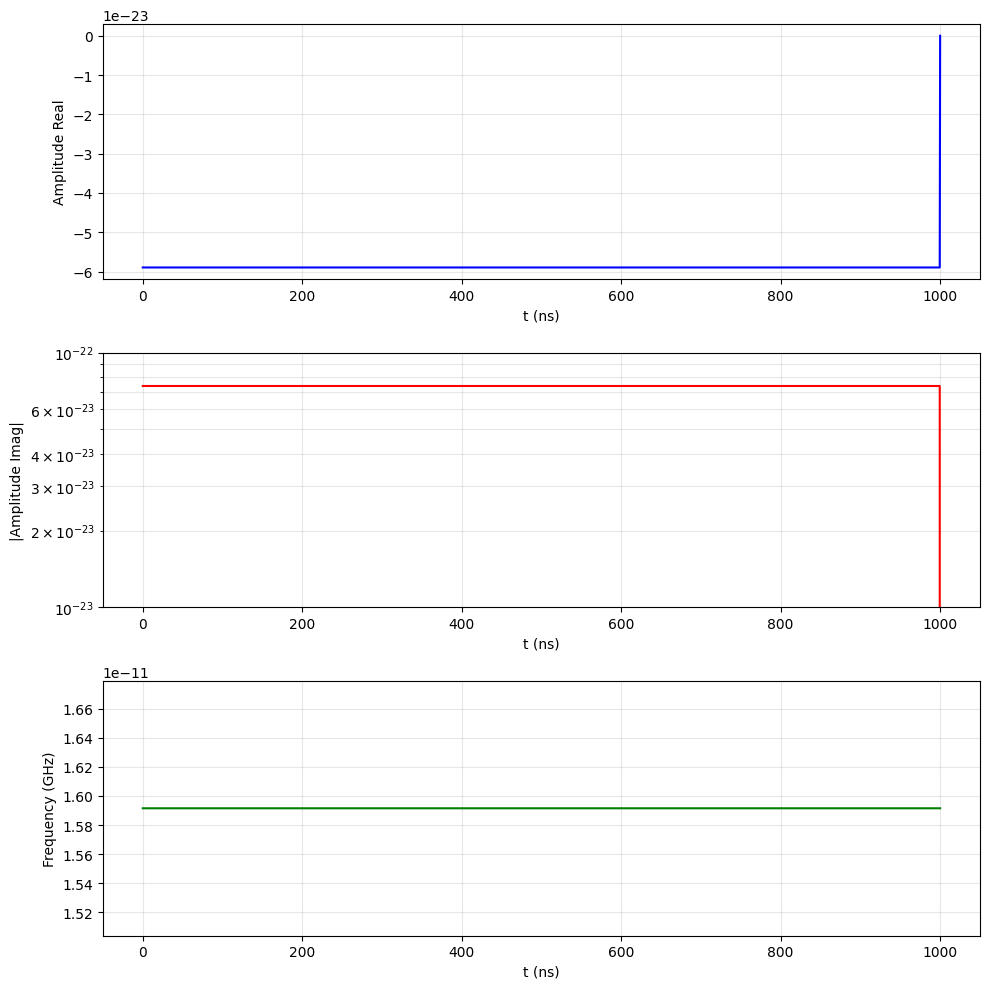

In [ ]:
def plot_drive_components(t_end=tg, n=2000):
    t_vals = np.linspace(0, t_end, n)
    amp_real = np.array([drive_amp_interp(t).real for t in t_vals])
    # extremwerte:
    print("min amp: ", min(amp_real), " max: ", max(amp_real))
    amp_imag = np.array([drive_amp_interp(t).imag for t in t_vals])
    freq = np.array([drive_wd_interp(t) for t in t_vals])
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))
    
    axes[0].plot(t_vals, amp_real, 'b-', linewidth=1.5)
    axes[0].set_xlabel('t (ns)')
    axes[0].set_ylabel('Amplitude Real')
    axes[0].grid(True, which='both', alpha=0.3)
    
    axes[1].plot(t_vals, np.abs(amp_imag), 'r-', linewidth=1.5)
    axes[1].set_yscale('log')
    axes[1].set_xlabel('t (ns)')
    axes[1].set_ylabel('|Amplitude Imag|')
    axes[1].grid(True, which='both', alpha=0.3)
    
    axes[2].plot(t_vals, freq/(2*np.pi), 'g-', linewidth=1.5)
    axes[2].set_xlabel('t (ns)')
    axes[2].set_ylabel('Frequency (GHz)')
    axes[2].grid(True, which='both', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
plot_drive_components()

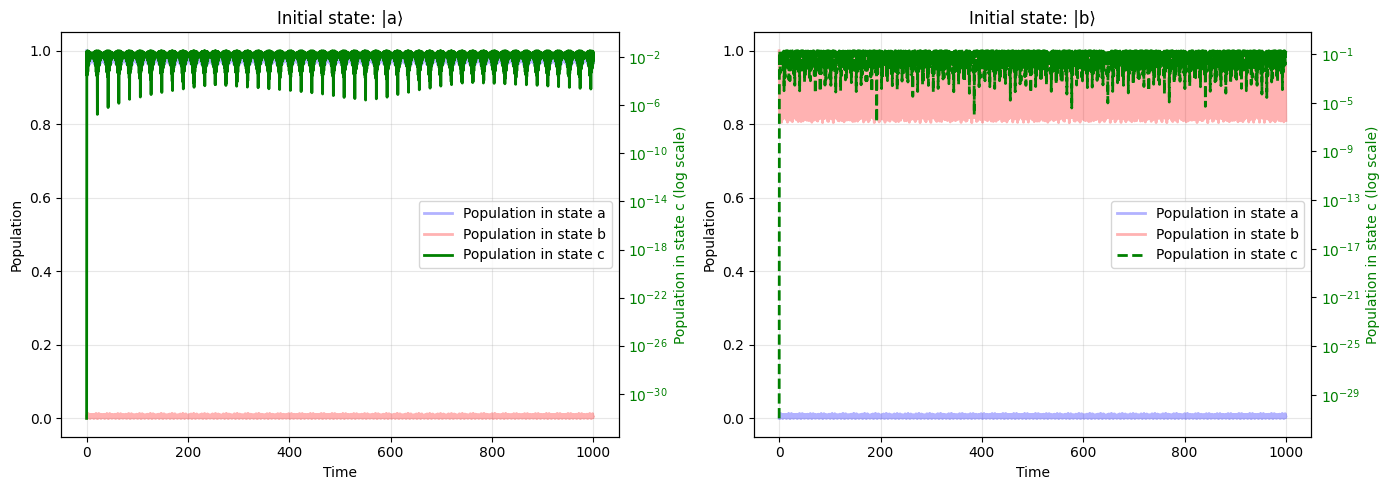

infidelity driven: 8.96e-01 pop: 5.06e-01


In [ ]:
# simulate the result directly over H0 and V1 from s 
tlist_fid = np.linspace(0, tg, 2500)
lh = [s.H0_dressed, [s.V1_dressed, drive_signal_interp]]
f_d = extract_fidelity(lh, tlist_fid, sim=s)
fpop_d = extract_pop_fid(lh, tlist_fid, plot=True, plot_c=True, s=s)['iswap_fidelity']
print(f"infidelity driven: {(1-f_d):.2e} pop: {(1-fpop_d):.2e}")